In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import shutil


# SALSA 数据集位置
src_path = "/kaggle/input/datasets/nus2828/salsa1/SALSA-main"

# 工作目录
dst_path = "/kaggle/working/SALSA"


# 如果之前存在，删除旧版本
if os.path.exists(dst_path):
    shutil.rmtree(dst_path)


# 复制
shutil.copytree(src_path, dst_path)


# 进入 SALSA
os.chdir(dst_path)


print("SALSA location:")
print(os.getcwd())

SALSA location:
/kaggle/working/SALSA


In [3]:
import os


print(os.listdir("."))

['CONTRIBUTING.md', 'README.md', 'LICENSE', 'notebooks', 'train.py', 'requirements.txt', 'CODE_OF_CONDUCT.md', '.gitignore', 'checkpoint', 'src', 'slurm_params']


In [4]:
import os

os.makedirs(
    "checkpoint",
    exist_ok=True
)

os.makedirs(
    "logs",
    exist_ok=True
)

print("checkpoint and logs ready")

checkpoint and logs ready


In [5]:
import shutil

src = "/kaggle/input/datasets/nus2828/salsa1/SALSA-main/src/trainer.py"
dst = "/kaggle/working/SALSA/src/trainer.py"

shutil.copy(src, dst)

print("trainer.py 已恢复")

trainer.py 已恢复


In [6]:
import os

file = "/kaggle/working/SALSA/src/optim.py"

with open(file, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "getargspec" in line:
        print("找到位置:", i+1)
        print(line)

找到位置: 335
    expected_args = inspect.getargspec(optim_fn.__init__)[0]



In [7]:
file = "/kaggle/working/SALSA/src/optim.py"

with open(file, "r") as f:
    content = f.read()

old = "inspect.getargspec(optim_fn.__init__)[0]"
new = "inspect.getfullargspec(optim_fn.__init__).args"

if old in content:
    content = content.replace(old, new)

    with open(file, "w") as f:
        f.write(content)

    print("✅ optim.py 修改完成")
else:
    print("❌ 没找到需要替换的代码")

✅ optim.py 修改完成


In [8]:
!grep -n "getfullargspec\|getargspec" /kaggle/working/SALSA/src/optim.py

335:    expected_args = inspect.getfullargspec(optim_fn.__init__).args


In [9]:
file="/kaggle/working/SALSA/src/evaluator.py"

with open(file,"r") as f:
    content=f.read()

old="""pred_bin2 = np.vectorize(lambda x: 0 if x != stats.mode(pred_final)[0][0] else 1)(pred_final)"""

new="""mode_value = stats.mode(pred_final).mode

        pred_bin2 = np.vectorize(
            lambda x: 0 if x != mode_value else 1
        )(pred_final)"""

if old in content:
    content=content.replace(old,new)

    with open(file,"w") as f:
        f.write(content)

    print("✅ evaluator.py 修复完成")
else:
    print("没有找到")

✅ evaluator.py 修复完成


In [10]:
path = "/kaggle/working/SALSA/src/trainer.py"

with open(path,"r") as f:
    lines=f.readlines()

for i,line in enumerate(lines):
    if "currPercQ" in line:
        print(i,line)

470         currPercQ = float(ast.literal_eval(scores["valid_lattice_percs_diff"])[0])

471         if currPercQ > self.best_10percQ:

472             self.best_10percQ = currPercQ

473             logger.info("New best score for toleranc=10percQ acc: %.6f" % (currPercQ))



In [11]:
path = "/kaggle/working/SALSA/src/trainer.py"

with open(path, "r") as f:
    content = f.read()


old = 'currPercQ = float(ast.literal_eval(scores["valid_lattice_percs_diff"])[0])'


new = '''
perc_str = scores["valid_lattice_percs_diff"]

# compatibility fix for numpy float representation
perc_str = perc_str.replace("np.float64(", "")
perc_str = perc_str.replace(")", "")

currPercQ = float(ast.literal_eval(perc_str)[0])
'''


if old in content:
    content = content.replace(old, new)
    print("modified")
else:
    print("target line not found")


with open(path, "w") as f:
    f.write(content)

modified


In [12]:
from pathlib import Path

file = Path("/kaggle/working/SALSA/src/trainer.py")

text = file.read_text()

old = text[text.index("currPercQ ="):text.index("logger.info", text.index("currPercQ ="))]

new = '''currPercQ = float(str(scores["valid_lattice_percs_diff"]).replace("np.float64(", "").replace(")", "").replace("[", "").split(",")[0])

        if currPercQ > self.best_10percQ:
            self.best_10percQ = currPercQ

            '''

text = text.replace(old, new)

file.write_text(text)

print("trainer.py 修复完成")

trainer.py 修复完成


In [13]:
path="/kaggle/working/SALSA/src/trainer.py"

with open(path,"r") as f:
    lines=f.readlines()

for i in range(len(lines)):
    if "if currPercQ > self.best_10percQ:" in lines[i]:
        lines[i] = "        if currPercQ > self.best_10percQ:\n"
    if "self.best_10percQ = currPercQ" in lines[i]:
        lines[i] = "            self.best_10percQ = currPercQ\n"

with open(path,"w") as f:
    f.writelines(lines)

print("indent fixed")

indent fixed


In [14]:
!python -m py_compile /kaggle/working/SALSA/src/trainer.py

Sorry: IndentationError: unexpected indent (trainer.py, line 480)

In [15]:
path = "/kaggle/working/SALSA/src/trainer.py"

with open(path, "r") as f:
    lines = f.readlines()

# 修改 470-485 行（Python下标，所以从469开始）
new_block = [
"        # Manually adding percs diff model saving.\n",
"\n",
"        perc_str = scores[\"valid_lattice_percs_diff\"]\n",
"\n",
"        # compatibility fix for numpy float representation\n",
"        perc_str = perc_str.replace(\"np.float64(\", \"\")\n",
"        perc_str = perc_str.replace(\")\", \"\")\n",
"\n",
"        currPercQ = float(perc_str.replace(\"[\", \"\").split(\",\")[0])\n",
"\n",
"        if currPercQ > self.best_10percQ:\n",
"            self.best_10percQ = currPercQ\n",
"\n",
"            logger.info(\"New best score for toleranc=10percQ acc: %.6f\" % (currPercQ))\n",
"            self.save_checkpoint(\"best-10percQ\")\n",
]

# 替换第470-485行
lines[469:485] = new_block

with open(path, "w") as f:
    f.writelines(lines)

print("trainer.py 已修复")

trainer.py 已修复


In [16]:
!python -m py_compile src/trainer.py

SALSA

 #测试

In [17]:
%cd /kaggle/working/SALSA

# 参数说明：
# --N 5            s的长度
# --sigma 3        e的大小（难度）
# --batch_size 8   每批样本大小
# --batch_size_eval 8  每批验证batch大小
# --max_epoch 1    最大遍历次数
# --epoch_size 100  一次遍历大小
# --eval_size 20   验证样本size
# --eval_verbose 0  不显示eval过程

!python train.py \
--dump_path './checkpoint/debug' \
--exp_name salsa_debug \
--env_name lattice \
--tasks lattice \
--operation circ_rlwe \
--N 4 \
--Q 20 \
--sigma 3 \
--batch_size 20 \
--batch_size_eval 20 \
--enc_emb_dim 128 \
--dec_emb_dim 128 \
--n_enc_layers 1 \
--n_dec_layers 1 \
--n_enc_heads 2 \
--n_dec_heads 2 \
--enc_loops 1 \
--dec_loops 1 \
--enc_loop_idx 0 \
--dec_loop_idx 0 \
--max_epoch 50 \
--epoch_size 100 \
--eval_size 20 \
--num_workers 0 \
--fp16 false \
--eval_verbose 0

/kaggle/working
/kaggle/working/SALSA/src/optim.py:283: SyntaxWarning: invalid escape sequence '\d'
  assert re.match("^[+-]?(\d+(\.\d*)?|\.\d+)$", split[1]) is not None
SLURM job: False
0 - Number of nodes: 1
0 - Node ID        : 0
0 - Local rank     : 0
0 - Global rank    : 0
0 - World size     : 1
0 - GPUs per node  : 1
0 - Master         : True
0 - Multi-node     : False
0 - Multi-GPU      : False
0 - Hostname       : fa41888b30e0
INFO - 08/14/26 04:10:23 - 0:00:00 - ============ Initialized logger ============
INFO - 08/14/26 04:10:23 - 0:00:00 - K: 1
                                     N: 4
                                     Q: 20
                                     accumulate_gradients: 1
                                     act_ponder_coupling: 0.05
                                     act_threshold: 0.01
                                     amp: -1
                                     attention_dropout: 0
                                     balanced_base: False
          

#小规模复现实验

In [18]:
%cd /kaggle/working/SALSA  
!python train.py \
--dump_path './checkpoint/test_small' \
--exp_name salsa_small \
--env_name lattice \
--tasks lattice \
--operation circ_rlwe \
--N 10 \
--Q 251 \
--sigma 3 \
--batch_size 16 \
--batch_size_eval 16 \
--enc_emb_dim 128 \
--dec_emb_dim 128 \
--n_enc_layers 2 \
--n_dec_layers 2 \
--n_enc_heads 4 \
--n_dec_heads 4 \
--enc_loops 1 \
--dec_loops 2 \
--max_epoch 3 \
--epoch_size 500 \
--eval_size 100 \
--num_workers 2 \
--fp16 false

/kaggle/working
SLURM job: False
0 - Number of nodes: 1
0 - Node ID        : 0
0 - Local rank     : 0
0 - Global rank    : 0
0 - World size     : 1
0 - GPUs per node  : 1
0 - Master         : True
0 - Multi-node     : False
0 - Multi-GPU      : False
0 - Hostname       : fa41888b30e0
INFO - 08/14/26 04:10:46 - 0:00:00 - ============ Initialized logger ============
INFO - 08/14/26 04:10:46 - 0:00:00 - K: 1
                                     N: 10
                                     Q: 251
                                     accumulate_gradients: 1
                                     act_ponder_coupling: 0.05
                                     act_threshold: 0.01
                                     amp: -1
                                     attention_dropout: 0
                                     balanced_base: False
                                     batch_load: False
                                     batch_size: 16
                                     batch_size_eval: 1

#观测loss是否下降

共找到 8 个 loss 值
loss 序列: [5.565942016514865, 5.5495606010610405, 5.554590745405718, 5.539615273475647, 5.5339497761292895, 5.535770936445757, 5.530917991291393, 5.162936719981107]


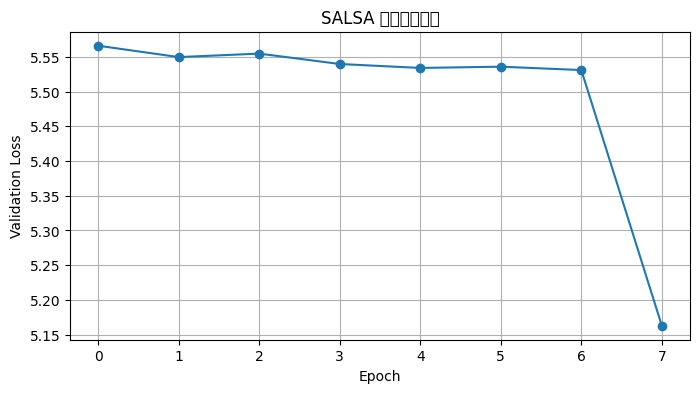

In [24]:
import re
import matplotlib.pyplot as plt

with open("/kaggle/working/SALSA/checkpoint/example/test_run/train.log", "r") as f:
    log = f.read()

losses = re.findall(r'"valid_lattice_xe_loss":\s*([\d.]+)', log)
losses = [float(x) for x in losses]

if losses:
    print(f"共找到 {len(losses)} 个 loss 值")
    print("loss 序列:", losses)
    
    plt.figure(figsize=(8,4))
    plt.plot(losses, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("SALSA  loss")
    plt.grid(True)
    plt.show()
else:
    print("未找到 loss 值，请确认训练已运行至少1个epoch，且 eval_verbose=1")